# Prophet 时序预测——项目数量

使用 Facebook Prophet 对月度累计项目数进行预测。

数据：`data/project.csv`（47行，月度，2022-03 ~ 2026-01）

训练集：前 80%（37行）；测试集：后 20%（10行）；预测步长：10个月

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data/project.csv')
df = df.rename(columns={'timestamp': 'ds', 'target': 'y'})[['ds', 'y']]
df['ds'] = pd.to_datetime(df['ds'])
print(f'数据行数: {len(df)}，时间范围: {df["ds"].min().date()} ~ {df["ds"].max().date()}')
df.tail(10)

数据行数: 47，时间范围: 2022-03-01 ~ 2026-01-01


,ds,y
37,2025-04-01,49
38,2025-05-01,51
39,2025-06-01,55
40,2025-07-01,56
41,2025-08-01,61
42,2025-09-01,62
43,2025-10-01,62
44,2025-11-01,64
45,2025-12-01,65
46,2026-01-01,66


训练集: 37 行  (2022-03-01 ~ 2025-03-01)
测试集: 10 行  (2025-04-01 ~ 2026-01-01)
预测步长: 10 个月


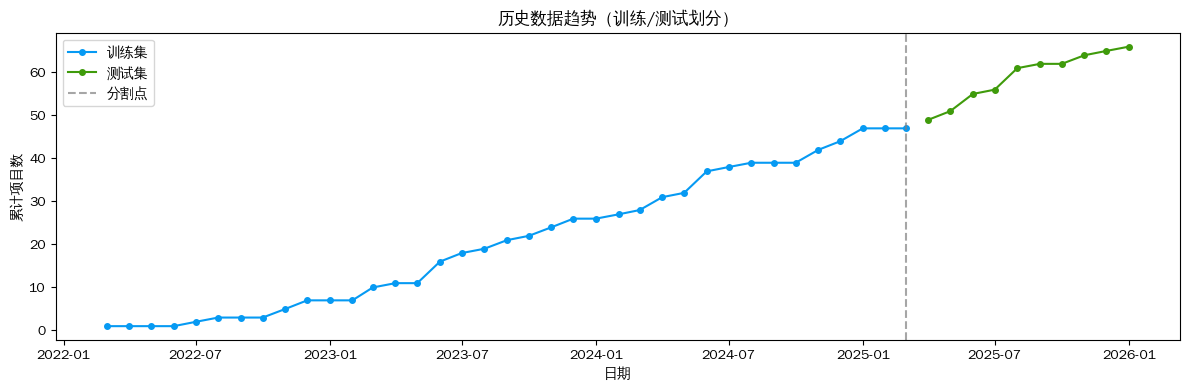

In [4]:
# 按 80/20 划分训练集和测试集
TRAIN_RATIO = 0.8
split_idx = int(len(df) * TRAIN_RATIO)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()
PRED_LEN = len(test_df)

print(f'训练集: {len(train_df)} 行  ({train_df["ds"].min().date()} ~ {train_df["ds"].max().date()})')
print(f'测试集: {len(test_df)} 行  ({test_df["ds"].min().date()} ~ {test_df["ds"].max().date()})')
print(f'预测步长: {PRED_LEN} 个月')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_df['ds'], train_df['y'], marker='o', markersize=4, color='xkcd:azure', label='训练集')
ax.plot(test_df['ds'],  test_df['y'],  marker='o', markersize=4, color='xkcd:grass green', label='测试集')
ax.axvline(x=train_df['ds'].iloc[-1], color='gray', linestyle='--', alpha=0.7, label='分割点')
ax.set_title('历史数据趋势（训练/测试划分）')
ax.set_xlabel('日期')
ax.set_ylabel('累计项目数')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# 月度累计序列使用 logistic 增长，cap 设为历史最大值 2 倍
cap_value   = df['y'].max() * 2
floor_value = 0

train_fit = train_df.copy()
train_fit['cap']   = cap_value
train_fit['floor'] = floor_value

m = Prophet(
    growth='logistic',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
)
m.fit(train_fit)
print('模型训练完成')

10:02:10 - cmdstanpy - INFO - Chain [1] start processing
10:02:10 - cmdstanpy - INFO - Chain [1] done processing


模型训练完成


In [6]:
# 向未来延伸 PRED_LEN 个月（与测试集对齐）
future = m.make_future_dataframe(periods=PRED_LEN, freq='MS')
future['cap']   = cap_value
future['floor'] = floor_value

forecast = m.predict(future)
forecast_test = forecast.tail(PRED_LEN)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].reset_index(drop=True)
print(f'预测期: {forecast_test["ds"].iloc[0].date()} ~ {forecast_test["ds"].iloc[-1].date()}')
forecast_test

预测期: 2025-04-01 ~ 2026-01-01


,ds,yhat,yhat_lower,yhat_upper
0,2025-04-01,56.124256,52.500451,59.863255
1,2025-05-01,57.887955,54.305537,61.339659
2,2025-06-01,62.235807,58.649710,65.775938
3,2025-07-01,65.261168,61.272031,68.771501
4,2025-08-01,67.589616,64.008259,71.459556
5,2025-09-01,69.245714,65.315643,73.093840
6,2025-10-01,71.388708,67.705121,74.766440
7,2025-11-01,74.863123,71.088489,78.482623
8,2025-12-01,78.063915,74.560228,81.775839
9,2026-01-01,79.688439,75.917362,83.461476


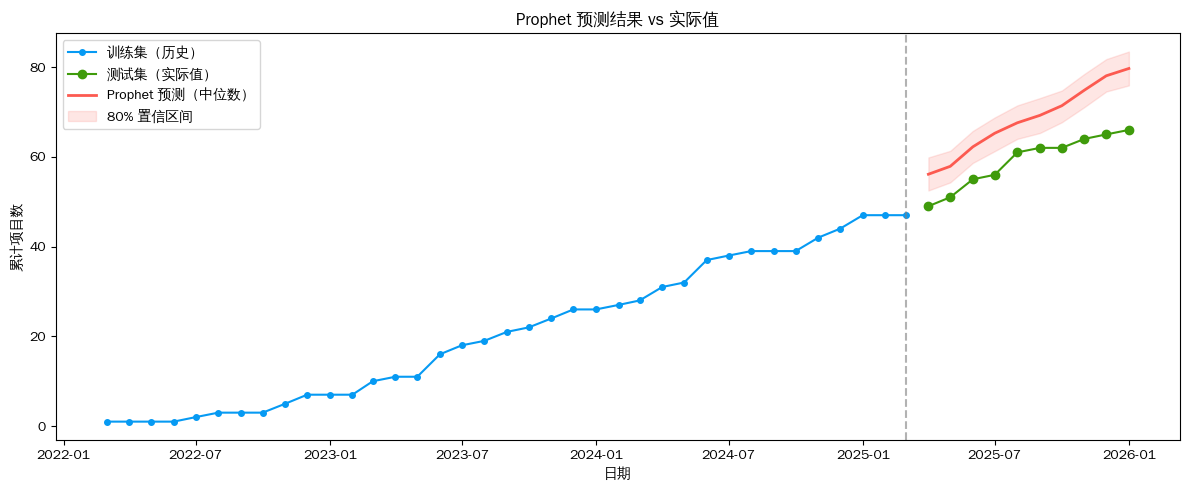

In [7]:
# 绘制预测结果 vs 实际值
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df['ds'], train_df['y'],
        color='xkcd:azure', marker='o', markersize=4, label='训练集（历史）')
ax.plot(test_df['ds'],  test_df['y'],
        color='xkcd:grass green', marker='o', markersize=6, label='测试集（实际值）')
ax.plot(forecast_test['ds'], forecast_test['yhat'],
        color='xkcd:coral', linewidth=2, label='Prophet 预测（中位数）')
ax.fill_between(forecast_test['ds'],
                forecast_test['yhat_lower'], forecast_test['yhat_upper'],
                color='xkcd:coral', alpha=0.15, label='80% 置信区间')
ax.axvline(x=train_df['ds'].iloc[-1], color='gray', linestyle='--', alpha=0.6)
ax.set_title('Prophet 预测结果 vs 实际值')
ax.set_xlabel('日期')
ax.set_ylabel('累计项目数')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# 误差指标：MAE、RMSE、MAPE
y_true = test_df['y'].values
y_pred = forecast_test['yhat'].values

mae  = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print('─' * 35)
print(f'  MAE  (平均绝对误差):      {mae:.3f}')
print(f'  RMSE (均方根误差):        {rmse:.3f}')
print(f'  MAPE (平均绝对百分误差):  {mape:.2f}%')
print('─' * 35)

───────────────────────────────────
  MAE  (平均绝对误差):      9.135
  RMSE (均方根误差):        9.468
  MAPE (平均绝对百分误差):  15.32%
───────────────────────────────────
